# RF-21 · Recomendaciones Inteligentes de Ahorro
**Módulo:** Objetivos de Ahorro  
**Prioridad:** 🟠 Should Have  
**Relacionado con:** HU-08, CU-03, RF-18, RF-22

---

Este notebook analiza patrones de ingresos y gastos para recomendar una cantidad de ahorro mensual realista dado un objetivo definido.

> **Nota:** Los datos de entrada son parámetros simulados. La conexión real con la app se realizará en una fase posterior.


In [1]:
import json
from datetime import datetime, date
from statistics import mean
from collections import defaultdict
from typing import Any


## 📥 Parámetros de Entrada
Esta celda está marcada con el tag `parameters` para ser inyectada por papermill desde la app.

In [2]:
# ──────────────────────────────────────────────────────────────────
# PARÁMETROS DE ENTRADA — sustituir por datos reales desde la app
# ──────────────────────────────────────────────────────────────────

# Lista de transacciones: cada una es un dict con fecha, tipo, monto, categoría
transacciones = [
    # INGRESOS
    {"fecha": "2024-11-01", "tipo": "ingreso",  "monto": 2100.00, "categoria": "salario"},
    {"fecha": "2024-11-15", "tipo": "ingreso",  "monto": 150.00,  "categoria": "freelance"},
    {"fecha": "2024-12-01", "tipo": "ingreso",  "monto": 2100.00, "categoria": "salario"},
    {"fecha": "2024-12-20", "tipo": "ingreso",  "monto": 200.00,  "categoria": "freelance"},
    {"fecha": "2025-01-01", "tipo": "ingreso",  "monto": 2100.00, "categoria": "salario"},

    # GASTOS
    {"fecha": "2024-11-03", "tipo": "gasto",    "monto": 750.00,  "categoria": "vivienda"},
    {"fecha": "2024-11-05", "tipo": "gasto",    "monto": 320.00,  "categoria": "alimentacion"},
    {"fecha": "2024-11-10", "tipo": "gasto",    "monto": 80.00,   "categoria": "transporte"},
    {"fecha": "2024-11-18", "tipo": "gasto",    "monto": 150.00,  "categoria": "ocio"},
    {"fecha": "2024-11-22", "tipo": "gasto",    "monto": 60.00,   "categoria": "suscripciones"},
    {"fecha": "2024-12-03", "tipo": "gasto",    "monto": 750.00,  "categoria": "vivienda"},
    {"fecha": "2024-12-07", "tipo": "gasto",    "monto": 400.00,  "categoria": "alimentacion"},
    {"fecha": "2024-12-12", "tipo": "gasto",    "monto": 90.00,   "categoria": "transporte"},
    {"fecha": "2024-12-24", "tipo": "gasto",    "monto": 300.00,  "categoria": "ocio"},
    {"fecha": "2024-12-28", "tipo": "gasto",    "monto": 60.00,   "categoria": "suscripciones"},
    {"fecha": "2025-01-03", "tipo": "gasto",    "monto": 750.00,  "categoria": "vivienda"},
    {"fecha": "2025-01-08", "tipo": "gasto",    "monto": 310.00,  "categoria": "alimentacion"},
    {"fecha": "2025-01-14", "tipo": "gasto",    "monto": 85.00,   "categoria": "transporte"},
    {"fecha": "2025-01-20", "tipo": "gasto",    "monto": 120.00,  "categoria": "ocio"},
    {"fecha": "2025-01-25", "tipo": "gasto",    "monto": 60.00,   "categoria": "suscripciones"},
]

# Objetivo de ahorro a evaluar
objetivo = {
    "nombre": "Vacaciones de verano",
    "monto_total": 3000.00,   # € a ahorrar
    "plazo_meses": 10,        # meses para alcanzarlo
}

# Compromisos de ahorro ya activos (objetivos en curso)
objetivos_existentes = [
    {"nombre": "Fondo de emergencia", "ahorro_mensual": 100.00},
    {"nombre": "Nuevo portátil",      "ahorro_mensual": 50.00},
]


## ⚙️ Funciones de Análisis
Lógica encapsulada en funciones para facilitar su extracción a un módulo `.py`.

In [3]:
def agrupar_por_mes(transacciones: list[dict]) -> dict:
    """Agrupa transacciones por año-mes y tipo."""
    meses: dict = defaultdict(lambda: {"ingresos": 0.0, "gastos": 0.0, "gastos_por_categoria": defaultdict(float)})
    for t in transacciones:
        clave = t["fecha"][:7]  # YYYY-MM
        if t["tipo"] == "ingreso":
            meses[clave]["ingresos"] += t["monto"]
        else:
            meses[clave]["gastos"] += t["monto"]
            meses[clave]["gastos_por_categoria"][t["categoria"]] += t["monto"]
    return dict(sorted(meses.items()))


def calcular_promedios(meses: dict) -> dict:
    """Calcula promedios mensuales de ingresos y gastos."""
    ingresos_list = [v["ingresos"] for v in meses.values()]
    gastos_list   = [v["gastos"]   for v in meses.values()]

    # Promedio de gastos por categoría
    categorias: dict = defaultdict(list)
    for v in meses.values():
        for cat, monto in v["gastos_por_categoria"].items():
            categorias[cat].append(monto)
    promedio_categorias = {cat: round(mean(montos), 2) for cat, montos in categorias.items()}

    return {
        "ingreso_promedio":  round(mean(ingresos_list), 2),
        "gasto_promedio":    round(mean(gastos_list), 2),
        "meses_analizados":  len(meses),
        "promedio_por_categoria": promedio_categorias,
    }


def calcular_capacidad_ahorro(promedios: dict, objetivos_existentes: list[dict]) -> dict:
    """Calcula cuánto puede ahorrar el usuario tras compromisos existentes."""
    ahorro_bruto = promedios["ingreso_promedio"] - promedios["gasto_promedio"]
    comprometido = sum(o["ahorro_mensual"] for o in objetivos_existentes)
    disponible   = ahorro_bruto - comprometido

    return {
        "ahorro_bruto":    round(ahorro_bruto, 2),
        "comprometido":    round(comprometido, 2),
        "disponible":      round(disponible, 2),
    }


def evaluar_objetivo(objetivo: dict, capacidad: dict) -> dict:
    """Evalúa si el objetivo es realista y genera recomendaciones."""
    monto_total  = objetivo["monto_total"]
    plazo_meses  = objetivo["plazo_meses"]
    disponible   = capacidad["disponible"]

    ahorro_necesario = round(monto_total / plazo_meses, 2)
    es_realista      = ahorro_necesario <= disponible
    porcentaje_uso   = round((ahorro_necesario / disponible * 100), 1) if disponible > 0 else float("inf")

    # Recomendación principal
    if disponible <= 0:
        ahorro_recomendado = 0.0
        alerta = "⛔ No tienes capacidad de ahorro disponible con tus patrones actuales."
    elif es_realista:
        ahorro_recomendado = ahorro_necesario
        alerta = None
    else:
        # Usar el 80% del disponible como máximo razonable
        ahorro_recomendado = round(disponible * 0.80, 2)
        alerta = f"⚠️ Para alcanzar {monto_total:.0f}€ en {plazo_meses} meses necesitas {ahorro_necesario:.0f}€/mes, pero solo tienes {disponible:.0f}€ libres."

    # Alternativas si no es realista
    alternativas = []
    if not es_realista and disponible > 0:
        plazo_alternativo = round(monto_total / ahorro_recomendado)
        alternativas.append({
            "tipo":        "plazo_mayor",
            "descripcion": f"Ahorrar {ahorro_recomendado:.0f}€/mes y alcanzar el objetivo en ~{plazo_alternativo} meses",
            "ahorro_mensual": ahorro_recomendado,
            "plazo_meses":    plazo_alternativo,
        })
        monto_alternativo = round(ahorro_necesario * 0.6, 2)
        plazo_alt2 = round(monto_total / monto_alternativo) if monto_alternativo > 0 else None
        alternativas.append({
            "tipo":        "monto_menor",
            "descripcion": f"Reducir el objetivo a {monto_alternativo:.0f}€/mes y alcanzarlo en ~{plazo_alt2} meses",
            "ahorro_mensual": monto_alternativo,
            "plazo_meses":    plazo_alt2,
        })

    return {
        "ahorro_necesario":   ahorro_necesario,
        "ahorro_recomendado": ahorro_recomendado,
        "es_realista":        es_realista,
        "porcentaje_disponible_usado": porcentaje_uso,
        "alerta":             alerta,
        "alternativas":       alternativas,
    }


def generar_justificacion(promedios: dict, capacidad: dict, evaluacion: dict, objetivo: dict) -> str:
    """Genera un texto explicativo en lenguaje simple para mostrar al usuario."""
    lineas = [
        f"📊 En los últimos {promedios['meses_analizados']} mes(es) analizados:",
        f"   • Ingresos promedio:  {promedios['ingreso_promedio']:.2f} €/mes",
        f"   • Gastos promedio:    {promedios['gasto_promedio']:.2f} €/mes",
        f"   • Ahorro bruto:       {capacidad['ahorro_bruto']:.2f} €/mes",
        f"   • Ya comprometido:    {capacidad['comprometido']:.2f} €/mes (otros objetivos)",
        f"   • Disponible libre:   {capacidad['disponible']:.2f} €/mes",
        "",
        f"🎯 Objetivo: {objetivo['nombre']} — {objetivo['monto_total']:.0f} € en {objetivo['plazo_meses']} meses",
        f"   → Necesitas ahorrar {evaluacion['ahorro_necesario']:.2f} €/mes",
        f"   → Recomendación:     {evaluacion['ahorro_recomendado']:.2f} €/mes ({evaluacion['porcentaje_disponible_usado']}% de tu capacidad libre)",
    ]

    if evaluacion["alerta"]:
        lineas += ["", evaluacion["alerta"]]

    if evaluacion["alternativas"]:
        lineas += ["", "💡 Alternativas sugeridas:"]
        for alt in evaluacion["alternativas"]:
            lineas.append(f"   • {alt['descripcion']}")

    return "\n".join(lineas)


## ▶️ Ejecución

In [4]:
# 1. Agrupar transacciones por mes
meses = agrupar_por_mes(transacciones)

# 2. Calcular promedios
promedios = calcular_promedios(meses)

# 3. Capacidad de ahorro disponible
capacidad = calcular_capacidad_ahorro(promedios, objetivos_existentes)

# 4. Evaluar objetivo
evaluacion = evaluar_objetivo(objetivo, capacidad)

# 5. Generar justificación
justificacion = generar_justificacion(promedios, capacidad, evaluacion, objetivo)

print(justificacion)


📊 En los últimos 3 mes(es) analizados:
   • Ingresos promedio:  2216.67 €/mes
   • Gastos promedio:    1428.33 €/mes
   • Ahorro bruto:       788.34 €/mes
   • Ya comprometido:    150.00 €/mes (otros objetivos)
   • Disponible libre:   638.34 €/mes

🎯 Objetivo: Vacaciones de verano — 3000 € en 10 meses
   → Necesitas ahorrar 300.00 €/mes
   → Recomendación:     300.00 €/mes (47.0% de tu capacidad libre)


## 📤 Salida Estructurada (JSON)
Este es el payload que devolverá el endpoint FastAPI cuando se integre con la app.

In [5]:
salida = {
    "objetivo": objetivo["nombre"],
    "analisis": {
        "meses_analizados":      promedios["meses_analizados"],
        "ingreso_promedio":      promedios["ingreso_promedio"],
        "gasto_promedio":        promedios["gasto_promedio"],
        "gasto_por_categoria":   promedios["promedio_por_categoria"],
    },
    "capacidad": capacidad,
    "recomendacion": {
        "ahorro_mensual_sugerido": evaluacion["ahorro_recomendado"],
        "es_realista":             evaluacion["es_realista"],
        "porcentaje_capacidad":    evaluacion["porcentaje_disponible_usado"],
        "alerta":                  evaluacion["alerta"],
        "alternativas":            evaluacion["alternativas"],
    },
    "justificacion": justificacion,
}

print(json.dumps(salida, ensure_ascii=False, indent=2))


{
  "objetivo": "Vacaciones de verano",
  "analisis": {
    "meses_analizados": 3,
    "ingreso_promedio": 2216.67,
    "gasto_promedio": 1428.33,
    "gasto_por_categoria": {
      "vivienda": 750.0,
      "alimentacion": 343.33,
      "transporte": 85.0,
      "ocio": 190.0,
      "suscripciones": 60.0
    }
  },
  "capacidad": {
    "ahorro_bruto": 788.34,
    "comprometido": 150.0,
    "disponible": 638.34
  },
  "recomendacion": {
    "ahorro_mensual_sugerido": 300.0,
    "es_realista": true,
    "porcentaje_capacidad": 47.0,
    "alerta": null,
    "alternativas": []
  },
  "justificacion": "📊 En los últimos 3 mes(es) analizados:\n   • Ingresos promedio:  2216.67 €/mes\n   • Gastos promedio:    1428.33 €/mes\n   • Ahorro bruto:       788.34 €/mes\n   • Ya comprometido:    150.00 €/mes (otros objetivos)\n   • Disponible libre:   638.34 €/mes\n\n🎯 Objetivo: Vacaciones de verano — 3000 € en 10 meses\n   → Necesitas ahorrar 300.00 €/mes\n   → Recomendación:     300.00 €/mes (47.0% de

## 📂 Detalle de Gastos por Categoría
Útil para identificar dónde se puede recortar si el objetivo no es realista.

In [6]:
print("Gasto promedio mensual por categoría:")
print("-" * 35)
categorias_ordenadas = sorted(
    promedios["promedio_por_categoria"].items(),
    key=lambda x: x[1],
    reverse=True
)
for cat, monto in categorias_ordenadas:
    barra = "█" * int(monto / 30)
    print(f"  {cat:<18} {monto:>8.2f} €  {barra}")


Gasto promedio mensual por categoría:
-----------------------------------
  vivienda             750.00 €  █████████████████████████
  alimentacion         343.33 €  ███████████
  ocio                 190.00 €  ██████
  transporte            85.00 €  ██
  suscripciones         60.00 €  ██


## 🔄 Simulación: ¿Qué pasa si cambian los patrones?
Criterio de aceptación: *«Actualización de recomendación si cambian patrones»*

Puedes modificar los valores de `nuevo_ingreso` y `nuevo_gasto` para simular escenarios.


In [7]:
# Simula un nuevo escenario de ingresos/gastos
nuevo_ingreso = promedios["ingreso_promedio"] * 1.10  # +10% de ingreso
nuevo_gasto   = promedios["gasto_promedio"]   * 0.95  # -5% de gasto

promedios_sim = {**promedios, "ingreso_promedio": round(nuevo_ingreso, 2), "gasto_promedio": round(nuevo_gasto, 2)}
capacidad_sim = calcular_capacidad_ahorro(promedios_sim, objetivos_existentes)
evaluacion_sim = evaluar_objetivo(objetivo, capacidad_sim)

print("📈 Escenario simulado (+10% ingreso, -5% gasto):")
print(f"   Capacidad disponible: {capacidad_sim['disponible']:.2f} €/mes")
print(f"   Ahorro recomendado:   {evaluacion_sim['ahorro_recomendado']:.2f} €/mes")
print(f"   ¿Es realista?:        {'Sí ✅' if evaluacion_sim['es_realista'] else 'No ❌'}")


📈 Escenario simulado (+10% ingreso, -5% gasto):
   Capacidad disponible: 931.43 €/mes
   Ahorro recomendado:   300.00 €/mes
   ¿Es realista?:        Sí ✅


---
# HU-08 · Recomendación Inteligente de Ahorro con IA

> **Historia de usuario:** Como usuario que establece un objetivo de ahorro, quiero que la app me diga cuánto debería ahorrar mensualmente de forma realista, para saber si mi objetivo es alcanzable.

Esta sección extiende el análisis del **RF-21** añadiendo:
- 🤖 Modelo ML para predecir capacidad de ahorro
- 🔍 Explicabilidad del modelo (SHAP)
- 📊 Visualización de impacto en presupuesto
- 🎛️ Ajuste interactivo de parámetros (ipywidgets)
- 👥 Comparación anónima con usuarios similares
- 🧪 A/B testing de estrategias de recomendación


## 📦 Dependencias adicionales (HU-08)

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score
import shap
import ipywidgets as widgets
from IPython.display import display, clear_output
import warnings
warnings.filterwarnings("ignore")

# Semilla para reproducibilidad
np.random.seed(42)
print("✅ Dependencias cargadas correctamente.")


✅ Dependencias cargadas correctamente.


## 👥 1. Dataset de Usuarios Anónimos
Datos sintéticos que simulan el historial agregado de otros usuarios de Finora.  
Cuando haya usuarios reales, este bloque se sustituirá por una query a la base de datos.


In [9]:
def generar_dataset_usuarios(n=500):
    """
    Genera un dataset sintético de usuarios con sus características financieras
    y la tasa de ahorro real que lograron alcanzar.
    Columnas (features):
        - ingreso_mensual
        - ratio_gasto_ingreso   (gastos / ingresos)
        - num_categorias_gasto
        - compromisos_previos   (€ ya comprometidos en otros objetivos)
        - plazo_objetivo_meses
        - monto_objetivo
    Target:
        - ahorro_real_logrado   (€/mes que realmente ahorraron)
    """
    ingresos    = np.random.normal(2200, 600, n).clip(900, 6000)
    ratio_gasto = np.random.beta(5, 3, n) * 0.95 + 0.05  # 5%-100%
    gastos      = ingresos * ratio_gasto
    compromisos = np.random.exponential(80, n).clip(0, 400)
    n_cats      = np.random.randint(2, 8, n).astype(float)
    plazo       = np.random.choice([3, 6, 12, 18, 24, 36], n).astype(float)
    monto_obj   = np.random.exponential(2500, n).clip(500, 20000)

    capacidad_real = (ingresos - gastos - compromisos).clip(0)
    # Añadir ruido realista: la gente no ahorra el 100% de su capacidad
    ruido = np.random.normal(0.75, 0.15, n).clip(0.3, 1.0)
    ahorro_logrado = (capacidad_real * ruido).round(2)

    X = np.column_stack([ingresos, ratio_gasto, n_cats, compromisos, plazo, monto_obj])
    y = ahorro_logrado
    feature_names = [
        "ingreso_mensual", "ratio_gasto_ingreso", "num_categorias_gasto",
        "compromisos_previos", "plazo_objetivo_meses", "monto_objetivo"
    ]
    return X, y, feature_names

X_usuarios, y_usuarios, FEATURE_NAMES = generar_dataset_usuarios(n=600)
print(f"Dataset generado: {X_usuarios.shape[0]} usuarios, {X_usuarios.shape[1]} features")
print(f"Ahorro promedio del dataset: {y_usuarios.mean():.2f} €/mes (σ={y_usuarios.std():.2f})")


Dataset generado: 600 usuarios, 6 features
Ahorro promedio del dataset: 515.55 €/mes (σ=310.76)


## 🤖 2. Modelo ML de Predicción de Capacidad de Ahorro
Se entrena un **Random Forest Regressor** con los datos del dataset de usuarios.  
En producción este modelo se entrenaría periódicamente con datos reales y se serializaría con `joblib`.


In [10]:
# Entrenamiento
modelo = RandomForestRegressor(n_estimators=150, max_depth=8, random_state=42, n_jobs=-1)
modelo.fit(X_usuarios, y_usuarios)

# Validación cruzada
scores = cross_val_score(modelo, X_usuarios, y_usuarios, cv=5, scoring="r2")
print(f"📈 R² cross-validation: {scores.mean():.3f} ± {scores.std():.3f}")
print(f"   (1.0 = perfecto, >0.7 = bueno para datos financieros ruidosos)")

# Preparar vector del usuario actual usando los resultados de RF-21
ratio_gasto_usuario  = round(promedios["gasto_promedio"] / promedios["ingreso_promedio"], 4)
num_cats_usuario     = len(promedios["promedio_por_categoria"])
comprometido_usuario = capacidad["comprometido"]
plazo_usuario        = float(objetivo["plazo_meses"])
monto_obj_usuario    = objetivo["monto_total"]

X_usuario_actual = np.array([[
    promedios["ingreso_promedio"],
    ratio_gasto_usuario,
    num_cats_usuario,
    comprometido_usuario,
    plazo_usuario,
    monto_obj_usuario,
]])

ahorro_predicho_ml = round(float(modelo.predict(X_usuario_actual)[0]), 2)
print(f"\n🎯 Predicción ML para el usuario actual: {ahorro_predicho_ml:.2f} €/mes de capacidad de ahorro")
print(f"   (Recomendación RF-21 basada en reglas: {evaluacion['ahorro_recomendado']:.2f} €/mes)")


📈 R² cross-validation: 0.835 ± 0.017
   (1.0 = perfecto, >0.7 = bueno para datos financieros ruidosos)

🎯 Predicción ML para el usuario actual: 440.69 €/mes de capacidad de ahorro
   (Recomendación RF-21 basada en reglas: 300.00 €/mes)


## 🔍 3. Explicabilidad del Modelo (SHAP)
Usamos **SHAP (SHapley Additive exPlanations)** para explicar por qué el modelo hace esa predicción concreta.  
Esto cumple el criterio de *«Explicabilidad del modelo»* de las Notas Técnicas.


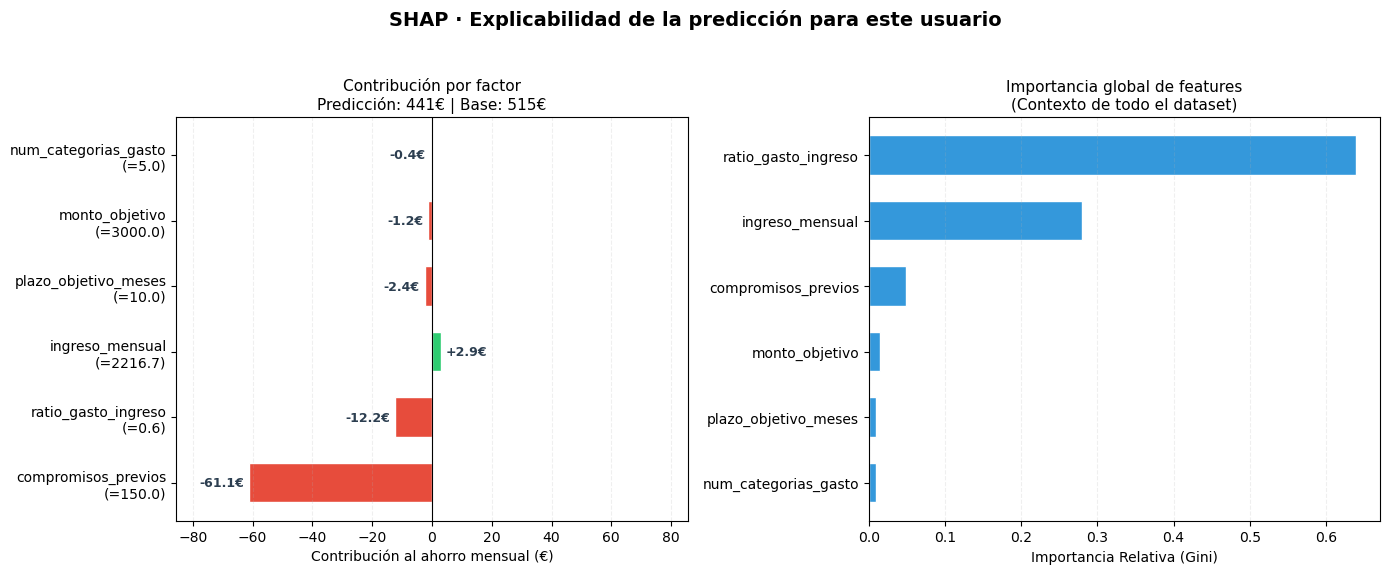


📋 Interpretación en lenguaje sencillo:
   • Compromisos previos: Al ser 150.0, reduce tu capacidad de ahorro en 61.1 €/mes.
   • Ratio gasto ingreso: Al ser 0.6, reduce tu capacidad de ahorro en 12.2 €/mes.
   • Ingreso mensual: Al ser 2216.7, aumenta tu capacidad de ahorro en 2.9 €/mes.
   • Plazo objetivo meses: Al ser 10.0, reduce tu capacidad de ahorro en 2.4 €/mes.
   • Monto objetivo: Al ser 3000.0, reduce tu capacidad de ahorro en 1.2 €/mes.
   • Num categorias gasto: Al ser 5.0, reduce tu capacidad de ahorro en 0.4 €/mes.


In [15]:
# 1. Calcular valores SHAP para el usuario actual
explainer   = shap.TreeExplainer(modelo)
shap_values = explainer.shap_values(X_usuario_actual)

# 2. Configuración de la figura
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("SHAP · Explicabilidad de la predicción para este usuario", fontsize=14, fontweight="bold")

# --- Gráfico 1: Impacto Local (Waterfall del usuario actual) ---
ax1 = axes[0]

# Asegurar que base_val sea un escalar
try:
    base_val = float(explainer.expected_value[0]) if isinstance(explainer.expected_value, (np.ndarray, list)) else float(explainer.expected_value)
except:
    base_val = float(explainer.expected_value)

shap_vals  = shap_values[0]
feat_vals  = X_usuario_actual[0]
contribs   = list(zip(FEATURE_NAMES, shap_vals, feat_vals))
contribs_s = sorted(contribs, key=lambda x: abs(x[1]), reverse=True)

# Preparar datos para el gráfico
labels = [f"{n}\n(={fv:.1f})" for n, _, fv in contribs_s]
vals   = [v for _, v, _ in contribs_s]
colors = ["#2ecc71" if v > 0 else "#e74c3c" for v in vals]

# Dibujar barras
bars = ax1.barh(labels, vals, color=colors, edgecolor="white", height=0.6)
ax1.axvline(0, color="black", linewidth=0.8)

# Ajuste dinámico de márgenes para que el texto no se corte
# Calculamos el valor máximo absoluto para dar aire a los lados
limit = max(abs(min(vals)), abs(max(vals))) * 1.4 if vals else 1
ax1.set_xlim(-limit, limit)

# Añadir etiquetas de valor a cada barra
for bar, val in zip(bars, vals):
    x_pos = val + (limit * 0.02) if val >= 0 else val - (limit * 0.02)
    ax1.text(x_pos, bar.get_y() + bar.get_height()/2,
             f"{val:+.1f}€", va="center", 
             ha="left" if val >= 0 else "right", 
             fontsize=9, fontweight="bold", color="#2c3e50")

ax1.set_xlabel("Contribución al ahorro mensual (€)")
ax1.set_title(f"Contribución por factor\nPredicción: {float(ahorro_predicho_ml):.0f}€ | Base: {base_val:.0f}€", fontsize=11)
ax1.grid(axis="x", alpha=0.2, linestyle='--')

# --- Gráfico 2: Importancia Global (Feature Importance) ---
ax2 = axes[1]
importancias = modelo.feature_importances_
idx = np.argsort(importancias)

ax2.barh([FEATURE_NAMES[i] for i in idx], importancias[idx],
         color="#3498db", edgecolor="white", height=0.6)

ax2.set_xlabel("Importancia Relativa (Gini)")
ax2.set_title("Importancia global de features\n(Contexto de todo el dataset)", fontsize=11)
ax2.grid(axis="x", alpha=0.2, linestyle='--')

# 3. Finalizar y guardar
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.savefig("shap_explicabilidad.png", dpi=120, bbox_inches="tight")
plt.show()

# 4. Interpretación textual
print("\n📋 Interpretación en lenguaje sencillo:")
for name, shap_val, feat_val in contribs_s:
    if abs(shap_val) > 0.1:  # Solo mostrar factores con impacto relevante
        impacto = "aumenta" if shap_val > 0 else "reduce"
        print(f"   • {name.replace('_', ' ').capitalize()}: Al ser {feat_val:.1f}, {impacto} tu capacidad de ahorro en {abs(shap_val):.1f} €/mes.")

## 📊 4. Visualización de Impacto en Presupuesto
Muestra cómo queda el presupuesto mensual tras aplicar la recomendación de ahorro.


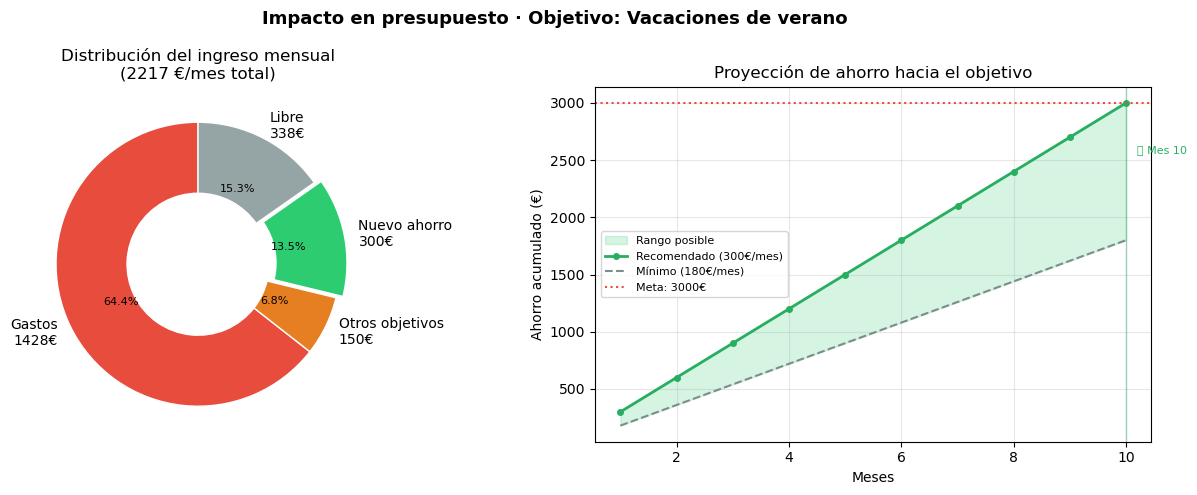

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle(f"Impacto en presupuesto · Objetivo: {objetivo['nombre']}", fontsize=13, fontweight="bold")

# ── Donut: distribución del ingreso ──────────────────────────────────────────
ahorro_final   = evaluacion["ahorro_recomendado"]
gasto_prom     = promedios["gasto_promedio"]
comprometido   = capacidad["comprometido"]
ingreso_prom   = promedios["ingreso_promedio"]
libre_restante = max(0, ingreso_prom - gasto_prom - comprometido - ahorro_final)

sizes  = [gasto_prom, comprometido, ahorro_final, libre_restante]
labels = [
    f"Gastos\n{gasto_prom:.0f}€",
    f"Otros objetivos\n{comprometido:.0f}€",
    f"Nuevo ahorro\n{ahorro_final:.0f}€",
    f"Libre\n{libre_restante:.0f}€",
]
colors_donut = ["#e74c3c", "#e67e22", "#2ecc71", "#95a5a6"]
explode = [0, 0, 0.05, 0]

wedges, texts, autotexts = axes[0].pie(
    sizes, labels=labels, colors=colors_donut, explode=explode,
    autopct=lambda p: f"{p:.1f}%" if p > 3 else "",
    startangle=90, wedgeprops=dict(width=0.5, edgecolor="white"),
)
for at in autotexts:
    at.set_fontsize(8)
axes[0].set_title(f"Distribución del ingreso mensual\n({ingreso_prom:.0f} €/mes total)")

# ── Barras: evolución hacia el objetivo ──────────────────────────────────────
meses_range   = list(range(1, objetivo["plazo_meses"] + 1))
acumulado_rec = [ahorro_final * m for m in meses_range]
acumulado_min = [ahorro_final * 0.6 * m for m in meses_range]
meta_line     = [objetivo["monto_total"]] * len(meses_range)

axes[1].fill_between(meses_range, acumulado_min, acumulado_rec,
                     alpha=0.2, color="#2ecc71", label="Rango posible")
axes[1].plot(meses_range, acumulado_rec, "o-", color="#27ae60",
             linewidth=2, markersize=4, label=f"Recomendado ({ahorro_final:.0f}€/mes)")
axes[1].plot(meses_range, acumulado_min, "--", color="#7f8c8d",
             linewidth=1.5, label=f"Mínimo ({ahorro_final*0.6:.0f}€/mes)")
axes[1].axhline(objetivo["monto_total"], color="#e74c3c", linewidth=1.5,
                linestyle=":", label=f"Meta: {objetivo['monto_total']:.0f}€")

# Marcar cuándo se alcanza la meta
for i, ac in enumerate(acumulado_rec):
    if ac >= objetivo["monto_total"]:
        axes[1].axvline(i + 1, color="#27ae60", alpha=0.4, linewidth=1)
        axes[1].annotate(f"✅ Mes {i+1}", xy=(i + 1, objetivo["monto_total"]),
                         xytext=(i + 1.2, objetivo["monto_total"] * 0.85),
                         fontsize=8, color="#27ae60")
        break

axes[1].set_xlabel("Meses")
axes[1].set_ylabel("Ahorro acumulado (€)")
axes[1].set_title("Proyección de ahorro hacia el objetivo")
axes[1].legend(fontsize=8)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("impacto_presupuesto.png", dpi=120, bbox_inches="tight")
plt.show()


## 👥 5. Comparación Anónima con Usuarios Similares
Busca usuarios del dataset con un perfil financiero parecido y muestra cuánto ahorran de media.  
Criterio de aceptación: *«Comparación con objetivos similares de otros usuarios (anónimo)»*


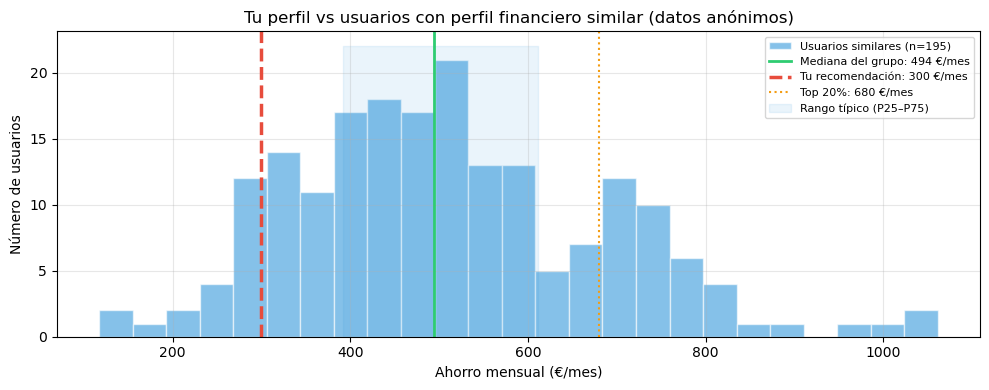


📊 Tu recomendación (300€/mes) está en el percentil 9.7 de usuarios similares.
   ℹ️ Usuarios con tu perfil suelen ahorrar más — considera revisar tus gastos.


In [19]:
def encontrar_usuarios_similares(X_ref, X_todos, y_todos, n_similares=50, tolerancia=0.20):
    """
    Encuentra usuarios con ingreso y ratio de gasto similares (±tolerancia%).
    Devuelve estadísticas de su ahorro real para comparación anónima.
    """
    ingreso_ref   = X_ref[0][0]
    ratio_ref     = X_ref[0][1]

    mascara = (
        (X_todos[:, 0] >= ingreso_ref * (1 - tolerancia)) &
        (X_todos[:, 0] <= ingreso_ref * (1 + tolerancia)) &
        (X_todos[:, 1] >= ratio_ref   * (1 - tolerancia)) &
        (X_todos[:, 1] <= ratio_ref   * (1 + tolerancia))
    )

    y_similares = y_todos[mascara]
    if len(y_similares) < 5:
        return None  # No hay suficientes usuarios similares

    return {
        "n_usuarios":       int(mascara.sum()),
        "ahorro_mediana":   round(float(np.median(y_similares)), 2),
        "ahorro_promedio":  round(float(np.mean(y_similares)), 2),
        "percentil_25":     round(float(np.percentile(y_similares, 25)), 2),
        "percentil_75":     round(float(np.percentile(y_similares, 75)), 2),
        "ahorro_top_20pct": round(float(np.percentile(y_similares, 80)), 2),
        "y_similares":      y_similares,
    }

similares = encontrar_usuarios_similares(X_usuario_actual, X_usuarios, y_usuarios)

if similares:
    fig, ax = plt.subplots(figsize=(10, 4))

    ax.hist(similares["y_similares"], bins=25, color="#3498db", alpha=0.6,
            edgecolor="white", label=f"Usuarios similares (n={similares['n_usuarios']})")
    ax.axvline(similares["ahorro_mediana"], color="#2ecc71", linewidth=2,
               label=f"Mediana del grupo: {similares['ahorro_mediana']:.0f} €/mes")
    ax.axvline(ahorro_final, color="#e74c3c", linewidth=2.5, linestyle="--",
               label=f"Tu recomendación: {ahorro_final:.0f} €/mes")
    ax.axvline(similares["ahorro_top_20pct"], color="#f39c12", linewidth=1.5,
               linestyle=":", label=f"Top 20%: {similares['ahorro_top_20pct']:.0f} €/mes")

    ax.fill_betweenx([0, ax.get_ylim()[1] if ax.get_ylim()[1] > 0 else 20],
                     similares["percentil_25"], similares["percentil_75"],
                     alpha=0.1, color="#3498db", label="Rango típico (P25–P75)")

    ax.set_xlabel("Ahorro mensual (€/mes)")
    ax.set_ylabel("Número de usuarios")
    ax.set_title("Tu perfil vs usuarios con perfil financiero similar (datos anónimos)")
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig("comparacion_usuarios.png", dpi=120, bbox_inches="tight")
    plt.show()

    percentil_usuario = round(float(np.mean(similares["y_similares"] <= ahorro_final) * 100), 1)
    print(f"\n📊 Tu recomendación ({ahorro_final:.0f}€/mes) está en el percentil {percentil_usuario} de usuarios similares.")
    if percentil_usuario >= 70:
        print("   💪 ¡Vas a ahorrar más que la mayoría de usuarios con tu perfil!")
    elif percentil_usuario >= 40:
        print("   👍 Tu objetivo está en línea con lo que logran usuarios similares.")
    else:
        print("   ℹ️ Usuarios con tu perfil suelen ahorrar más — considera revisar tus gastos.")
else:
    print("ℹ️ No hay suficientes usuarios similares en el dataset para hacer comparación.")


## 🎛️ 6. Ajuste Interactivo de Parámetros
Permite al usuario explorar cómo cambia la recomendación al modificar el objetivo.  
Criterio de aceptación: *«Ajuste de parámetros interactivo»*

> **Nota:** Requiere Jupyter Lab/Notebook con ipywidgets instalado. En el entorno Docker asegúrate de tener `jupyter nbextension enable --py widgetsnbextension`.


In [20]:
def recalcular_y_mostrar(monto_objetivo, plazo_meses, reduccion_gastos_pct):
    """Recalcula la recomendación con los parámetros del usuario y muestra el resultado."""
    # Ajustar gastos con la reducción elegida
    gasto_ajustado = promedios["gasto_promedio"] * (1 - reduccion_gastos_pct / 100)
    promedios_adj  = {**promedios, "gasto_promedio": round(gasto_ajustado, 2)}
    capacidad_adj  = calcular_capacidad_ahorro(promedios_adj, objetivos_existentes)

    objetivo_adj   = {**objetivo, "monto_total": monto_objetivo, "plazo_meses": plazo_meses}
    evaluacion_adj = evaluar_objetivo(objetivo_adj, capacidad_adj)

    # Predicción ML con los nuevos parámetros
    ratio_nuevo = round(gasto_ajustado / promedios["ingreso_promedio"], 4)
    X_nuevo = np.array([[
        promedios["ingreso_promedio"], ratio_nuevo, num_cats_usuario,
        comprometido_usuario, float(plazo_meses), float(monto_objetivo),
    ]])
    ml_pred = round(float(modelo.predict(X_nuevo)[0]), 2)

    print(f"{'─'*55}")
    print(f"  Monto objetivo:      {monto_objetivo:.0f} €")
    print(f"  Plazo:               {plazo_meses} meses")
    print(f"  Reducción de gastos: {reduccion_gastos_pct:.0f}%  → Gasto ajustado: {gasto_ajustado:.0f} €/mes")
    print(f"  Capacidad libre:     {capacidad_adj['disponible']:.2f} €/mes")
    print(f"{'─'*55}")
    print(f"  📐 Recomendación (reglas): {evaluacion_adj['ahorro_recomendado']:.2f} €/mes")
    print(f"  🤖 Predicción ML:          {ml_pred:.2f} €/mes")
    print(f"  ¿Es realista?:             {'Sí ✅' if evaluacion_adj['es_realista'] else 'No ❌'}")
    if evaluacion_adj["alerta"]:
        print(f"\n  {evaluacion_adj['alerta']}")
    if evaluacion_adj["alternativas"]:
        print("\n  💡 Alternativas:")
        for alt in evaluacion_adj["alternativas"]:
            print(f"     • {alt['descripcion']}")

# ── Widgets ───────────────────────────────────────────────────────────────────
w_monto = widgets.FloatSlider(
    value=objetivo["monto_total"], min=500, max=20000, step=250,
    description="Meta (€):", layout=widgets.Layout(width="450px"),
    style={"description_width": "100px"}
)
w_plazo = widgets.IntSlider(
    value=objetivo["plazo_meses"], min=1, max=48, step=1,
    description="Plazo (m):", layout=widgets.Layout(width="450px"),
    style={"description_width": "100px"}
)
w_reduccion = widgets.FloatSlider(
    value=0.0, min=0.0, max=30.0, step=1.0,
    description="Recorte (%):", layout=widgets.Layout(width="450px"),
    style={"description_width": "100px"},
    tooltip="% de reducción de tus gastos actuales"
)
output = widgets.Output()

def on_change(change):
    with output:
        clear_output(wait=True)
        recalcular_y_mostrar(w_monto.value, w_plazo.value, w_reduccion.value)

w_monto.observe(on_change, names="value")
w_plazo.observe(on_change, names="value")
w_reduccion.observe(on_change, names="value")

display(widgets.VBox([
    widgets.HTML("<h4 style='margin:0'>🎛️ Ajusta los parámetros del objetivo</h4>"),
    w_monto, w_plazo, w_reduccion, output
]))
recalcular_y_mostrar(w_monto.value, w_plazo.value, w_reduccion.value)


───────────────────────────────────────────────────────
  Monto objetivo:      3000 €
  Plazo:               10 meses
  Reducción de gastos: 0%  → Gasto ajustado: 1428 €/mes
  Capacidad libre:     638.34 €/mes
───────────────────────────────────────────────────────
  📐 Recomendación (reglas): 300.00 €/mes
  🤖 Predicción ML:          440.69 €/mes
  ¿Es realista?:             Sí ✅


## 🧪 7. A/B Testing de Estrategias de Recomendación
Compara dos estrategias de recomendación para determinar cuál es más efectiva.  
En producción, el flag de variante se inyectaría como parámetro desde la app.


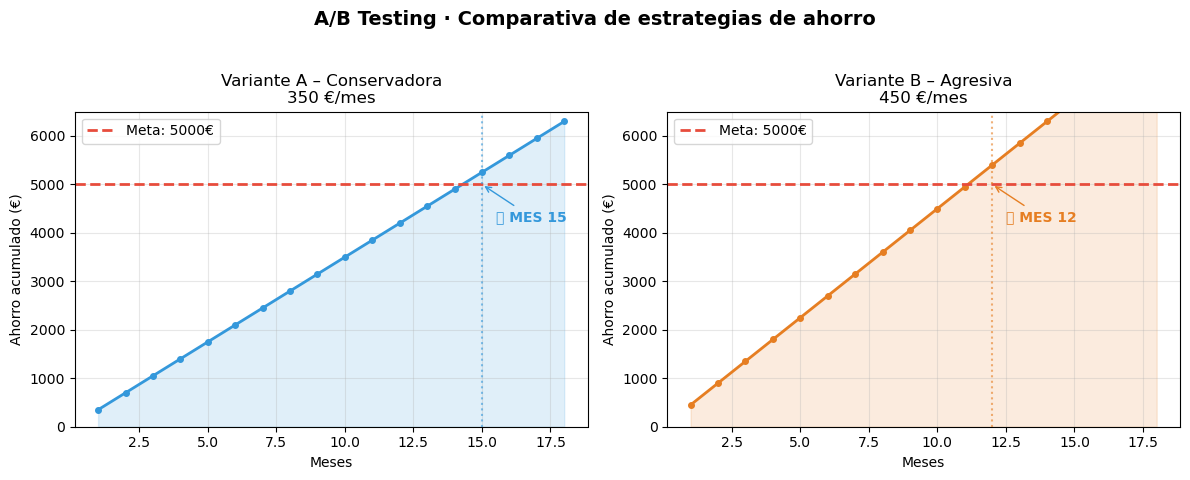


🧪 Variante asignada: A – A – Conservadora
👉 Recomendación: 350.00 €/mes


In [25]:
import matplotlib.pyplot as plt

# ── Datos de simulación ajustados para ver diferencias claras ────────────────
# Con 500€ de capacidad y meta de 5000€:
# El mínimo para llegar en 12 meses sería 416€/mes.
capacidad = {"disponible": 500} 
objetivo = {"monto_total": 5000, "plazo_meses": 12}

# ── Definición de estrategias ────────────────────────────────────────────────
def estrategia_A(capacidad, objetivo):
    """Variante A: recomendación conservadora (tope del 70% de capacidad)."""
    # Prioriza la tranquilidad: si el objetivo requiere más del 70%, se queda en el 70%.
    rec = round(min(
        objetivo["monto_total"] / objetivo["plazo_meses"],
        capacidad["disponible"] * 0.70
    ), 2)
    return {"variante": "A – Conservadora", "ahorro_mensual": rec,
            "descripcion": "70% de capacidad, menor estrés mensual"}

def estrategia_B(capacidad, objetivo):
    """Variante B: recomendación agresiva (usa el 90% de capacidad)."""
    # Prioriza la velocidad: usa el 90% para terminar lo antes posible.
    rec = round(capacidad["disponible"] * 0.90, 2)
    return {"variante": "B – Agresiva", "ahorro_mensual": rec,
            "descripcion": "90% de capacidad, alcanza el objetivo mucho antes"}

resultado_A = estrategia_A(capacidad, objetivo)
resultado_B = estrategia_B(capacidad, objetivo)

# ── Asignación de variante (simulada) ───────────────
variante_asignada = "A"  
variante_activa = resultado_A if variante_asignada == "A" else resultado_B

# ── Comparativa visual ───────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("A/B Testing · Comparativa de estrategias de ahorro", fontsize=14, fontweight="bold")

variantes    = [resultado_A, resultado_B]
colores_ab   = ["#3498db", "#e67e22"]
# Extendemos el rango a 18 meses para ver cómo la conservadora tarda más
meses_range  = list(range(1, 19)) 

for ax, var, color in zip(axes, variantes, colores_ab):
    acum = [var["ahorro_mensual"] * m for m in meses_range]
    meta = objetivo["monto_total"]

    ax.plot(meses_range, acum, "o-", color=color, linewidth=2, markersize=4)
    ax.axhline(meta, color="#e74c3c", linewidth=2, linestyle="--", label=f"Meta: {meta}€")
    ax.fill_between(meses_range, acum, alpha=0.15, color=color)

    # Identificar el mes en que se cruza la meta
    for i, ac in enumerate(acum):
        if ac >= meta:
            ax.axvline(i + 1, color=color, alpha=0.6, linestyle=":")
            ax.annotate(f"✅ MES {i+1}", xy=(i+1, meta),
                        xytext=(i+1.5, meta*0.85), fontsize=10, fontweight="bold",
                        color=color, arrowprops=dict(arrowstyle="->", color=color))
            break

    ax.set_title(f"Variante {var['variante']}\n{var['ahorro_mensual']:.0f} €/mes", fontsize=12)
    ax.set_xlabel("Meses")
    ax.set_ylabel("Ahorro acumulado (€)")
    ax.set_ylim(0, meta * 1.3)
    ax.grid(alpha=0.3)
    ax.legend(loc="upper left")

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.savefig("ab_testing_diferenciado.png", dpi=120)
plt.show()

print(f"\n🧪 Variante asignada: {variante_asignada} – {variante_activa['variante']}")
print(f"👉 Recomendación: {variante_activa['ahorro_mensual']:.2f} €/mes")

## 📤 Salida Final Combinada (RF-21 + HU-08)
Payload JSON completo que devolverá el endpoint cuando se integre con la app.

In [26]:
salida_completa = {
    **salida,  # todo el payload de RF-21
    "hu08": {
        "prediccion_ml": {
            "ahorro_mensual_predicho": ahorro_predicho_ml,
            "modelo": "RandomForestRegressor",
            "r2_cv_mean": round(float(scores.mean()), 3),
        },
        "explicabilidad": {
            "top_factores": [
                {"factor": name, "contribucion_eur": round(float(val), 2)}
                for name, val, _ in sorted(
                    zip(FEATURE_NAMES, shap_values[0], X_usuario_actual[0]),
                    key=lambda x: abs(x[1]), reverse=True
                )[:3]
            ]
        },
        "comparacion_anonima": {
            "n_usuarios_similares": similares["n_usuarios"] if similares else 0,
            "mediana_grupo":        similares["ahorro_mediana"] if similares else None,
            "percentil_usuario":    percentil_usuario if similares else None,
        } if similares else {"disponible": False},
        "ab_testing": {
            "variante_asignada": variante_asignada,
            "ahorro_recomendado_variante": variante_activa["ahorro_mensual"],
        },
    }
}

print(json.dumps(salida_completa, ensure_ascii=False, indent=2))


{
  "objetivo": "Vacaciones de verano",
  "analisis": {
    "meses_analizados": 3,
    "ingreso_promedio": 2216.67,
    "gasto_promedio": 1428.33,
    "gasto_por_categoria": {
      "vivienda": 750.0,
      "alimentacion": 343.33,
      "transporte": 85.0,
      "ocio": 190.0,
      "suscripciones": 60.0
    }
  },
  "capacidad": {
    "ahorro_bruto": 788.34,
    "comprometido": 150.0,
    "disponible": 638.34
  },
  "recomendacion": {
    "ahorro_mensual_sugerido": 300.0,
    "es_realista": true,
    "porcentaje_capacidad": 47.0,
    "alerta": null,
    "alternativas": []
  },
  "justificacion": "📊 En los últimos 3 mes(es) analizados:\n   • Ingresos promedio:  2216.67 €/mes\n   • Gastos promedio:    1428.33 €/mes\n   • Ahorro bruto:       788.34 €/mes\n   • Ya comprometido:    150.00 €/mes (otros objetivos)\n   • Disponible libre:   638.34 €/mes\n\n🎯 Objetivo: Vacaciones de verano — 3000 € en 10 meses\n   → Necesitas ahorrar 300.00 €/mes\n   → Recomendación:     300.00 €/mes (47.0% de